In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [63]:
def percentDiff(x1,x2):
    return abs(x1 - x2)/abs(x1) * 100

In [64]:
simulation_results = pd.read_csv("random_candidates_ansys_results.csv")
ML_results = pd.read_csv("random_candidates_for_ansys_validation.csv")

In [65]:
pred_surr_pd_frequency = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}
pred_tar_pd_frequency = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}
pred_surr_pd_alpha = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}
pred_tar_pd_alpha = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}

for i in range(len(simulation_results)):

    current_design = ML_results.iloc[i]

    claw = current_design["design_options.connection_pads.readout.claw_length"]
    ground = current_design["design_options.connection_pads.readout.ground_spacing"]
    cross = current_design["design_options.cross_length"]

    ''' for now drop unphysical designs by hand '''
    if i == 25 or i == 47 or i == 48 or i == 51:
        continue
    else:
        current = simulation_results.iloc[i]
        current_sigma = int(current.sigma_for_gauss)
        pred_H_params = current.pred_H_params
        surrogate_H_params = current.surrogate_H_params
        target_H_params = current.target_H_params
    
        pd_pred_surr_frequency = percentDiff(eval(surrogate_H_params)["qubit_frequency_GHz"],eval(pred_H_params)["qubit_frequency_GHz"])
        pd_pred_tar_frequency = percentDiff(eval(target_H_params)["qubit_frequency_GHz"],eval(pred_H_params)["qubit_frequency_GHz"])
        pd_pred_surr_alpha = percentDiff(eval(surrogate_H_params)["anharmonicity_MHz"],eval(pred_H_params)["anharmonicity_MHz"])
        pd_pred_tar_alpha = percentDiff(eval(target_H_params)["anharmonicity_MHz"],eval(pred_H_params)["anharmonicity_MHz"])
    
        pred_surr_pd_frequency[str(current_sigma)] += [pd_pred_surr_frequency]
        pred_surr_pd_alpha[str(current_sigma)] += [pd_pred_surr_alpha]
        pred_tar_pd_frequency[str(current_sigma)] += [pd_pred_tar_frequency]
        pred_tar_pd_alpha[str(current_sigma)] += [pd_pred_tar_alpha]

# percent differences between target/surrogate and prediction vs $\sigma_{\text{noise}}$

## $f_q$ percent differences (Ansys vs Surrogate & Ansys vs Target)

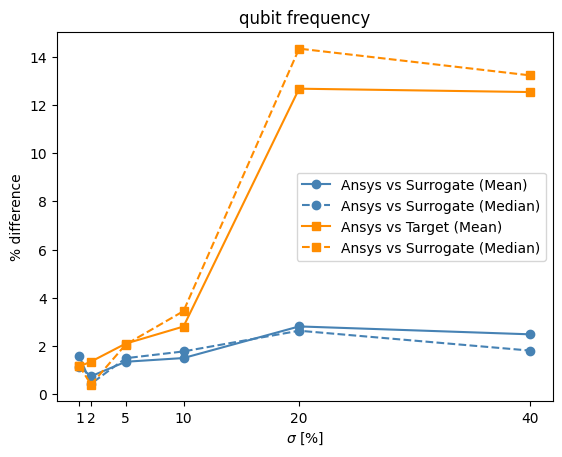

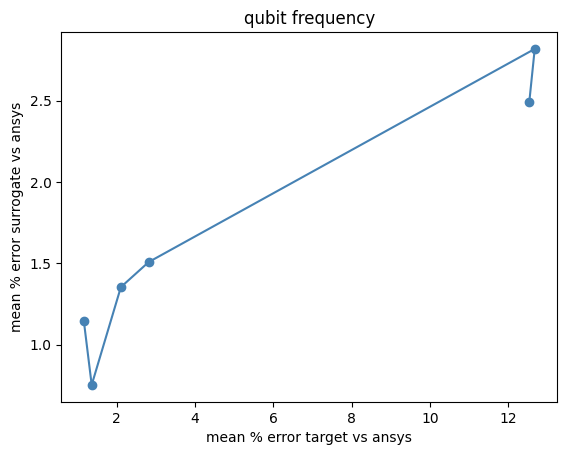

In [66]:
x = []
surrogate_means_f = []
surrogate_medians_f = []
target_means_f = []
target_medians_f = []

for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_frequency = pred_surr_pd_frequency[key]
    current_pred_tar_pd_frequency = pred_tar_pd_frequency[key]
    x.append(int(key))
    surrogate_means_f.append(np.mean(current_pred_surr_pd_frequency))
    target_means_f.append(np.mean(current_pred_tar_pd_frequency))
    surrogate_medians_f.append(np.median(current_pred_surr_pd_frequency))
    target_medians_f.append(np.median(current_pred_tar_pd_frequency))
    
plt.plot(x,surrogate_means_f,color = "steelblue",marker = "o",label = "Ansys vs Surrogate (Mean)")
plt.plot(x,surrogate_medians_f,color = "steelblue",marker = "o",linestyle = "dashed",label = "Ansys vs Surrogate (Median)")
plt.plot(x,target_means_f,color = "darkorange",marker = "s",label = "Ansys vs Target (Mean)")
plt.plot(x,target_medians_f,color = "darkorange",marker = "s",linestyle = "dashed",label = "Ansys vs Surrogate (Median)")
plt.xticks(x,x)
plt.title("qubit frequency")
plt.legend()
plt.ylabel("% difference")
plt.xlabel(r"$\sigma$ [%]")
plt.show()

plt.plot(target_means_f,surrogate_means_f,color = "steelblue",marker = "o",label = "Ansys vs Surrogate (Mean)")
plt.ylabel(r"mean % error surrogate vs ansys")
plt.xlabel(r"mean % error target vs ansys")
plt.title("qubit frequency")
plt.show()

## $\alpha$ percent differences (Ansys vs Surrogate & Ansys vs Target)

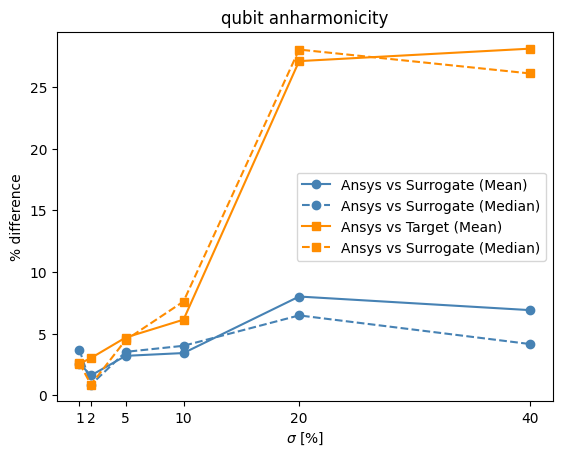

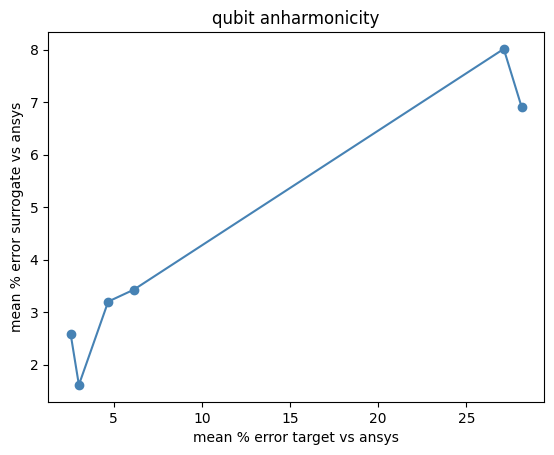

In [67]:
surrogate_means_alpha = []
surrogate_medians_alpha = []
target_means_alpha = []
target_medians_alpha = []
for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_alpha = pred_surr_pd_alpha[key]
    current_pred_tar_pd_alpha = pred_tar_pd_alpha[key]
    surrogate_means_alpha.append(np.mean(current_pred_surr_pd_alpha))
    target_means_alpha.append(np.mean(current_pred_tar_pd_alpha))
    surrogate_medians_alpha.append(np.median(current_pred_surr_pd_alpha))
    target_medians_alpha.append(np.median(current_pred_tar_pd_alpha))
    
    
plt.plot(x,surrogate_means_alpha,color = "steelblue",marker = "o",label = "Ansys vs Surrogate (Mean)")
plt.plot(x,surrogate_medians_alpha,color = "steelblue",marker = "o",linestyle = "dashed",label = "Ansys vs Surrogate (Median)")
plt.plot(x,target_means_alpha,color = "darkorange",marker = "s",label = "Ansys vs Target (Mean)")
plt.plot(x,target_medians_alpha,color = "darkorange",marker = "s",linestyle = "dashed",label = "Ansys vs Surrogate (Median)")
plt.xticks(x,x)
plt.title("qubit anharmonicity")
plt.legend()
plt.ylabel("% difference")
plt.xlabel(r"$\sigma$ [%]")
plt.xticks(x,x)
plt.show()

plt.plot(target_means_alpha,surrogate_means_alpha,color = "steelblue",marker = "o",label = "Ansys vs Surrogate (Mean)")
plt.ylabel(r"mean % error surrogate vs ansys")
plt.xlabel(r"mean % error target vs ansys")
plt.title("qubit anharmonicity")
plt.show()

## Box plot versions of above plots

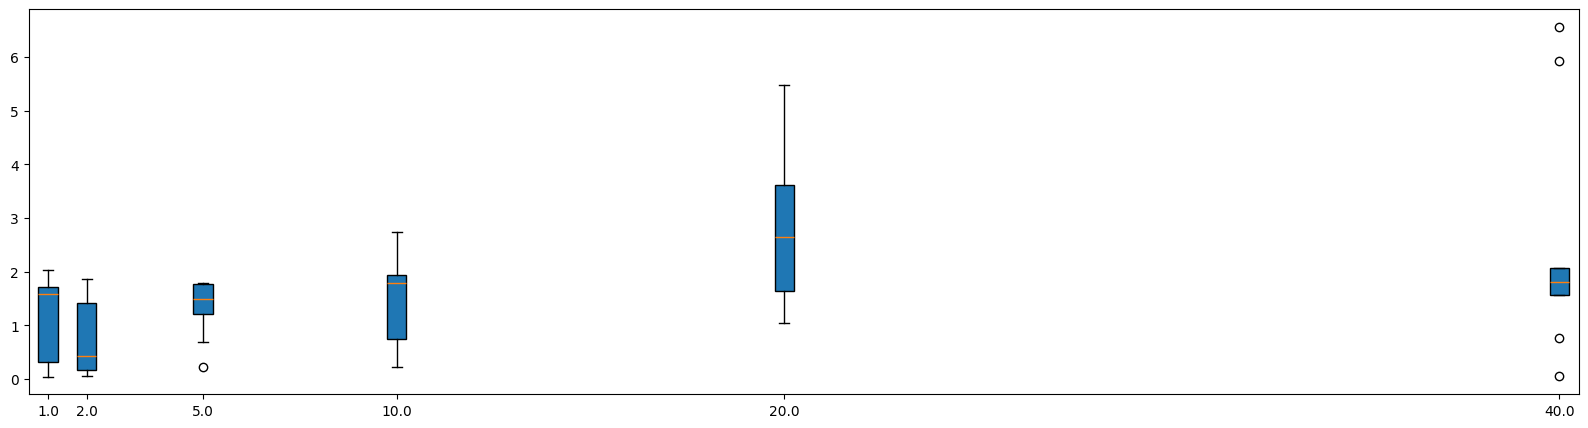

In [68]:
fig,ax = plt.subplots(figsize = (20,5))

for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_frequency = pred_surr_pd_frequency[key]
    current_pred_tar_pd_frequency = pred_tar_pd_frequency[key]

    target_mean = np.mean(current_pred_tar_pd_frequency)

    ''' plot box plots against mean percent change between ansys and target '''
    #plt.boxplot([pred_surr_pd_frequency[key]],positions=[float(target_mean)],widths=.1,patch_artist=True)
    

    ''' plot box plots against gaussian sigma ''' 
    plt.boxplot([pred_surr_pd_frequency[key]],positions=[float(key)],widths=.5,patch_artist=True)

    # plt.plot(target_means,surrogate_means,color = "steelblue",marker = "o",label = "Ansys vs Surrogate (Mean)")
    # plt.ylabel(r"mean % error surrogate vs ansys")
    # plt.xlabel(r"mean % error target vs ansys")
    # plt.title("qubit frequency")
    # plt.show()

# Hamiltonian parameter scatter plots per $\sigma$

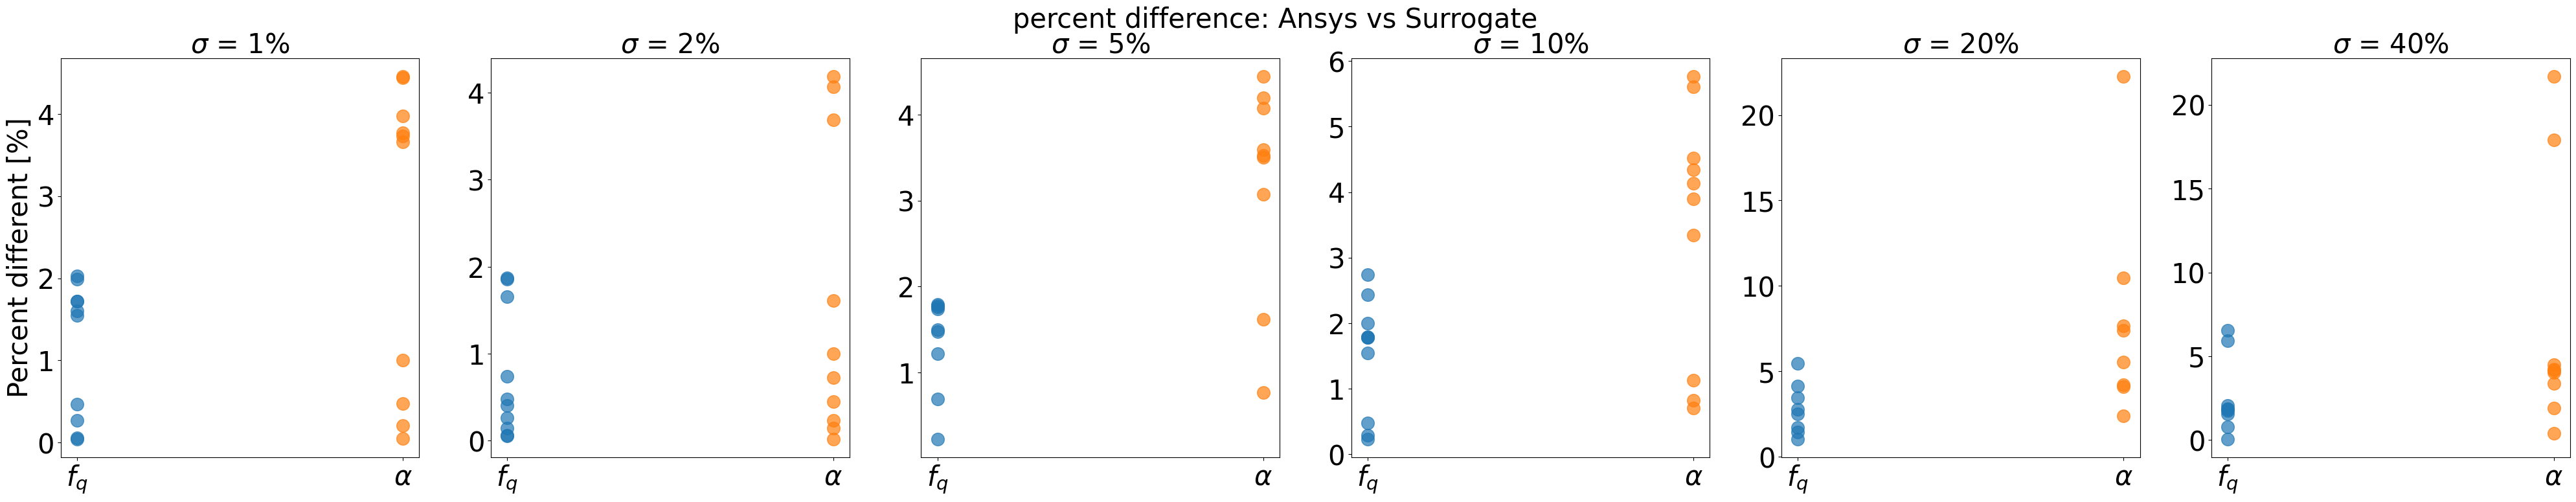

In [69]:
fig,ax = plt.subplots(1,len(pred_surr_pd_frequency),figsize = (50,8))
ax_count = 0
for key in pred_surr_pd_frequency:

    freq_y = pred_surr_pd_frequency[key]
    alpha_y = pred_surr_pd_alpha[key]

    ax[ax_count].scatter([r"$f_q$"]*len(freq_y),freq_y,color = "C0",s = 200,alpha = 0.7)
    ax[ax_count].scatter([r"$\alpha$"]*len(alpha_y),alpha_y,color = "C1",s = 200,alpha = 0.7)
    
    ax[ax_count].tick_params("y",labelsize = 30)
    ax[ax_count].tick_params("x",labelsize = 30)
    ax[ax_count].set_title(r"$\sigma$ = {}%".format(key),fontsize = 30)
    ax[0].set_ylabel("Percent different [%]",fontsize =30)

    ax_count += 1

    
fig.suptitle("percent difference: Ansys vs Surrogate",fontsize = 30)
plt.savefig("Ansys_vs_surrogate.png",bbox_inches='tight')

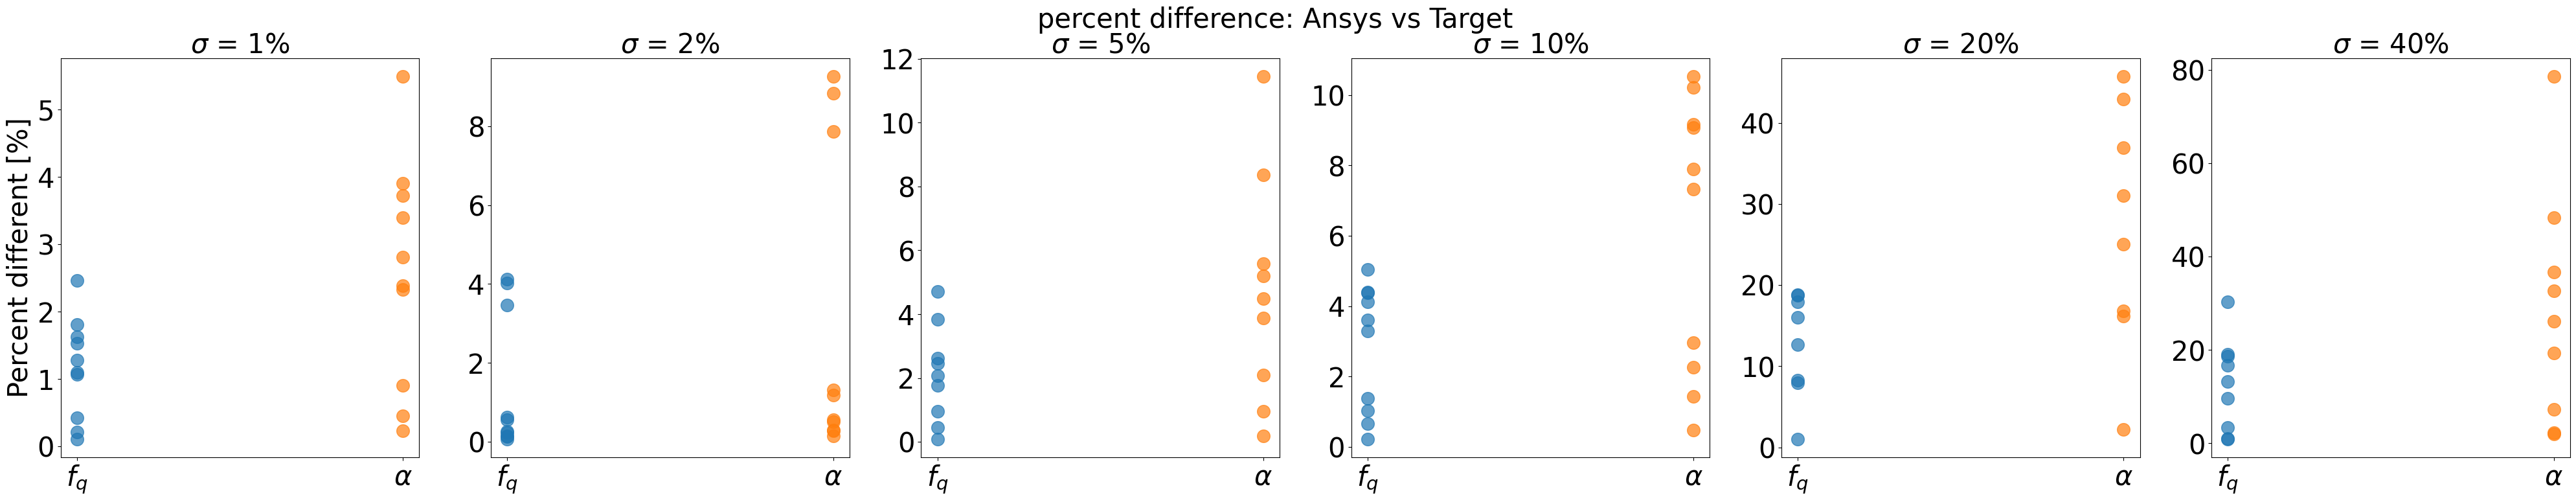

In [70]:
fig,ax = plt.subplots(1,len(pred_surr_pd_frequency),figsize = (50,8))
ax_count = 0
for key in pred_surr_pd_frequency:

    freq_y = pred_tar_pd_frequency[key]
    alpha_y = pred_tar_pd_alpha[key]

    ax[ax_count].scatter([r"$f_q$"]*len(freq_y),freq_y,color = "C0",s = 200,alpha = 0.7)
    ax[ax_count].scatter([r"$\alpha$"]*len(alpha_y),alpha_y,color = "C1",s = 200,alpha = 0.7)
    
    ax[ax_count].tick_params("y",labelsize = 30)
    ax[ax_count].tick_params("x",labelsize = 30)
    ax[ax_count].set_title(r"$\sigma$ = {}%".format(key),fontsize = 30)
    ax[0].set_ylabel("Percent different [%]",fontsize =30)

    ax_count += 1

fig.suptitle("percent difference: Ansys vs Target",fontsize = 30)
plt.savefig("Ansys_vs_target.png",bbox_inches='tight')